<a href="https://colab.research.google.com/github/jmmarinr/ComputationalMethods/blob/master/Calculo/Aleatorios_MonteCarlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Librerias

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from mpl_toolkits.mplot3d import Axes3D

# Teoría de los Números Aleatorios

---
### Profesor: Juan Marcos Marín
---

Los **números aleatorios** son una secuencia de valores generados de manera que no existe un patrón determinista entre ellos. En la práctica computacional, los números aleatorios que se utilizan son generados por algoritmos deterministas, por lo cual se denominan *números pseudoaleatorios*.

## Generadores Pseudoaleatorios (PRNG)
Un **Generador Pseudoaleatorio de Números (PRNG)** es un algoritmo que, a partir de una semilla inicial (`seed`), produce una secuencia de números con propiedades estadísticas similares a los verdaderos aleatorios.

### Características de los PRNG:
- Determinismo: la misma semilla produce la misma secuencia.
- Período largo: la secuencia no se repite hasta después de muchos valores.
- Uniformidad: los valores están distribuidos uniformemente en el rango objetivo.
- Independencia aparente: los valores no presentan correlación entre ellos.

## Algoritmos comunes:
- **Mersenne Twister**: fue el algoritmo por defecto en NumPy hasta la versión 1.16.
- **PCG64**: es el generador moderno por defecto al usar `default_rng()` desde NumPy 1.17. Es más seguro, reproducible y con mejor rendimiento.

## Tipos de distribuciones
Las funciones de generación de números aleatorios en NumPy permiten simular variables aleatorias con distintas distribuciones de probabilidad, por ejemplo:
- Distribución uniforme (continua o discreta)
- Distribución normal (gaussiana)
- Distribuciones discretas como binomial y Poisson
- Distribuciones continuas como exponencial, gamma, beta, etc.

Esto permite realizar simulaciones estadísticas, experimentos Monte Carlo, y modelamiento probabilístico en diversos campos científicos.


## Método Congruencial Lineal (LCG)

Este es uno de los generadores más antiguos y simples. La secuencia de números se calcula mediante:

$$
X_{n+1} = (a X_n + c) \mod m,
$$

donde:
- $X_n$ es el número generado en el paso $n$,
- $a$ es el multiplicador,
- $c$ es el incremento,
- $m$ es el módulo,
- $X_0$ es la semilla inicial.

El valor generado se normaliza a $[0, 1)$ mediante:

$$
U_n = \frac{X_n}{m}.
$$

---

## Ejemplo



Usando los parámetros para C++ :
* **Módulo ($m$)**: $2^{31} - 1 = 2147483647$
* **Multiplicador ($a$)**: $48271$
* **Incremento ($c$)**: $0$
* **Semilla ($X_0$)**: $4$

### Primer número ($X_0$) y su normalización ($U_0$)

$X_0 = 4$

Normalizamos $X_0$:
$$U_0 = \frac{X_0}{m} = \frac{4}{2147483647}$$

$U_0 \approx 0.000000001862645149230957$

### Segundo número ($X_1$) y su normalización ($U_1$)

Ya calculamos $X_1$ previamente:
$X_1 = (aX_0 + c) \pmod m = (48271 \times 4 + 0) \pmod {2^{31} - 1} = 193084 \pmod {2147483647} = 193084$

Normalizamos $X_1$:
$$U_1 = \frac{X_1}{m} = \frac{193084}{2147483647}$$

$U_1 \approx 0.00008991107567794354$







In [ ]:
# Parámetros del LCG
m_val = 2**31 - 1 # Modulo
a_val = 48271 # Multiplicador
c_val = 0 # Incremento
seed_val = 4 # Semilla
num_gen = 1000 # Generaremos 10 números

# Generar la secuencia
X = [seed_val]
for _ in range(num_gen - 1):
    X.append((a_val * X[-1] + c_val) % m_val)

# Normalizar a [0, 1)
U = [x / m_val for x in X]


print(f"Primer número normalizado (U[0]): {U[0]}")
print(f"Segundo número normalizado (U[1]): {U[1]}")


Primer número normalizado (U[0]): 1.8626451500983188e-09
Segundo número normalizado (U[1]): 8.991174404039595e-05


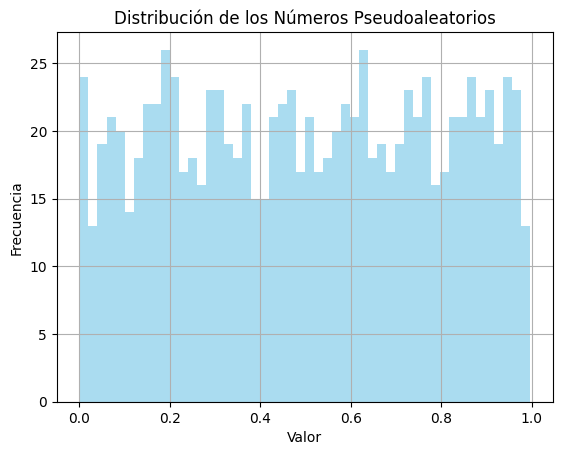

In [ ]:
plt.hist(U, bins=50, alpha=0.7, color='skyblue')
plt.title("Distribución de los Números Pseudoaleatorios")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()


# Generación de Números Aleatorios con `numpy.random`

La sublibrería `numpy.random` de Python permite generar números aleatorios con diferentes distribuciones estadísticas. Estos métodos son ampliamente utilizados en simulaciones, análisis estadísticos, algoritmos estocásticos y ciencia de datos.

A partir de NumPy 1.17, se recomienda usar el generador `numpy.random.default_rng()` como enfoque moderno para la generación de números aleatorios.

In [ ]:
# Generador moderno
rng = np.random.default_rng(seed=42)  # Semilla fija para reproducibilidad

In [ ]:
# Generador uniforme

rng.random(size=5)  # Uniforme continua en [0, 1)

array([0.77395605, 0.43887844, 0.85859792, 0.69736803, 0.09417735])

In [ ]:
# Generador uniforme

rng.uniform(low=10, high=20, size=5)  # Uniforme continua en [10, 20)

array([19.75622352, 17.61139702, 17.86064305, 11.28113633, 14.50385938])

In [ ]:
# Generador enteros

rng.integers(low=0, high=10, size=5)  # Enteros en [0, 10)

array([5, 3, 1, 9, 7])

## Distribuciones comunes adicionales


[ 1.12724121  0.46750934 -0.85929246  0.36875078 -0.9588826 ]


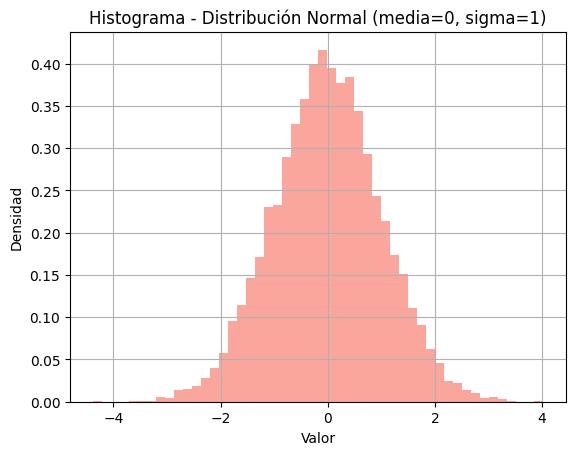

In [ ]:
data = rng.standard_normal(size=5)  # Normal estándar (media 0, sigma 1)
print(data) # 5 datos
data = rng.normal(loc=0, scale=1, size=10000)
plt.hist(data, bins=50, density=True, alpha=0.7, color='salmon')
plt.title('Histograma - Distribución Normal (media=0, sigma=1)')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

In [ ]:
rng.normal(loc=10, scale=2, size=5)  # Normal general (media 10, sigma 2)

array([ 7.66808615,  9.60410474,  9.51152674, 10.83591821,  9.98260326])

[7 7 8 3 4]


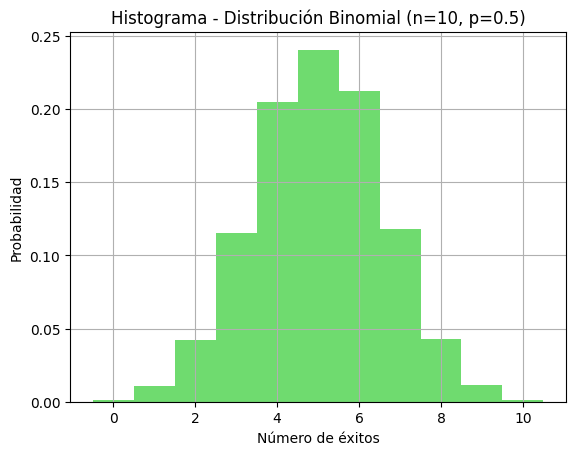

In [ ]:
data = rng.binomial(n=10, p=0.5, size=5)  # Binomial
print(data)

data = rng.binomial(n=10, p=0.5, size=10000)
plt.hist(data, bins=range(12), align='left', density=True, alpha=0.7, color='limegreen')
plt.title('Histograma - Distribución Binomial (n=10, p=0.5)')
plt.xlabel('Número de éxitos')
plt.ylabel('Probabilidad')
plt.grid(True)
plt.show()

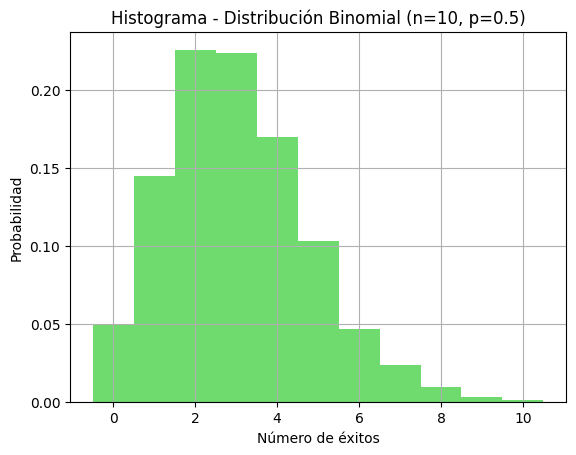

In [ ]:
rng.poisson(lam=3.0, size=5)  # Poisson

data = rng.poisson(lam = 3.0, size=10000)
plt.hist(data, bins=range(12), align='left', density=True, alpha=0.7, color='limegreen')
plt.title('Histograma - Distribución Binomial (n=10, p=0.5)')
plt.xlabel('Número de éxitos')
plt.ylabel('Probabilidad')
plt.grid(True)
plt.show()

# Resolución de Integrales Usando el Método de Monte Carlo

El método de Monte Carlo es una técnica probabilística utilizada para aproximar soluciones de problemas matemáticos, como la integración. Este enfoque es particularmente útil para integrales de funciones complejas o en espacios de alta dimensión donde los métodos tradicionales resultan imprácticos.

La integración por Monte Carlo se basa en el promedio de los valores de la función evaluada en puntos aleatorios dentro del dominio de integración. La integral definida de una función $f(x)$ en el intervalo $[a, b]$ se puede escribir como:

$$
I = \int_a^b f(x) \, dx
$$

Reformulando, si generamos puntos $x_1, x_2, \dots, x_N$ distribuidos uniformemente en $[a, b]$, la integral se aproxima mediante:

$$
I \approx \frac{b-a}{N} \sum_{i=1}^N f(x_i),
$$

donde $N$ es el número de puntos aleatorios generados.

En problemas de mayor dimensión, donde el dominio es más complejo, se calcula la integral en una región $\Omega$ utilizando la fórmula:

$$
I \approx \frac{\text{Vol}(\Omega)}{N} \sum_{i=1}^N f(x_i),
$$

donde $\text{Vol}(\Omega)$ es el volumen del dominio $\Omega$, y los puntos $x_i$ se distribuyen uniformemente en $\Omega$.







### **Ejemplo 1: Integral de una función unidimensional**

Resolver la integral:

$$
I = \int_0^1 e^{-x^2} \, dx
$$

1. **Paso 1: Generar puntos aleatorios.** Generamos $N$ puntos uniformemente distribuidos en $[0, 1]$.
2. **Paso 2: Evaluar la función.** Calculamos $f(x) = e^{-x^2}$ para cada punto.
3. **Paso 3: Calcular la integral.** Usamos la fórmula:

$$
I \approx \frac{1-0}{N} \sum_{i=1}^N f(x_i).
$$

---


In [ ]:
# Parámetros
N = 1000  # Número de puntos
a, b = 0, 1  # Límites de integración

# Generar puntos aleatorios
x = rng.uniform(a, b, N)

# Evaluar la función
f_x = np.exp(-x**2)

# Aproximar la integral
integral = (b - a) * np.mean(f_x)

print(f'El valor de la integral por MC será: {integral}')

f = lambda x: np.exp(-x**2)
integral_exact = quad(f, a, b)[0]
print(f'El valor de la integral exacta será: {integral_exact}')

print('##'*20)
error = np.abs(integral - integral_exact) * 100 / integral_exact
print(f'El error absoluto es: {error} %')

El valor de la integral por MC será: 0.7423438513917014
El valor de la integral exacta será: 0.7468241328124271
########################################
El error absoluto es: 0.5999111737128241 %


# Rejection Sampling para Integración Monte Carlo


Calculemos la integral definida de una función no negativa f(x) sobre un intervalo [a, b]:

$$
I = \int_a^b f(x)\,dx
$$


En lugar de muestrear directamente según $f(x)$, usamos una distribución auxiliar $g(x)$ tal que:

- $f(x) ≤ M g(x)$ para todo $x ∈ [a, b]$, con $M > 0$
- $g(x)$ es una función de densidad de probabilidad en $[a, b]$, es decir:

$$
\int_a^b g(x)\,dx = 1
$$

Luego generamos muestras de $x$ según $g(x)$ y las aceptamos con probabilidad proporcional a $f(x)/(M g(x))$.


## Algoritmo (versión geométrica para integración)

1. Supongamos $f(x) ≥ 0$ en [a, b] y que existe una cota $f_max$ tal que $f(x) ≤ f_{max}$.
2. Generar N puntos uniformes $(x_i, y_i)$ en el rectángulo $[a, b] × [0, f_{max}]$.
3. Contar cuántos puntos caen bajo la curva: $y_i ≤ f(x_i)$
4. Estimar la integral como:

$$
I \approx (b - a) \cdot f_{\text{max}} \cdot \frac{\text{número de puntos aceptados}}{N}
$$





Integral estimada: 0.750100


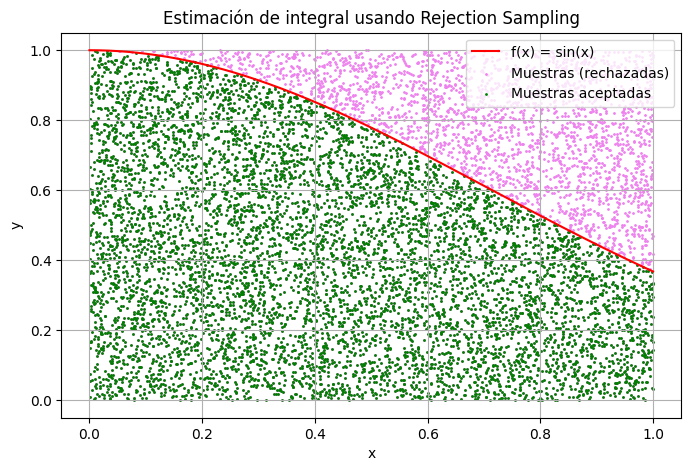

In [ ]:
# Definimos la función que queremos integrar
# En este caso: f(x) = exp(-x**2), sobre el intervalo [0, 1]
f = lambda x: np.exp(-x**2)

# Intervalo de integración
a, b = 0, 1

# Cota superior conocida de f(x) en el intervalo [a, b]
# Como e^{- x^2} alcanza su máximo en 0, sabemos que f_max = 1
f_max = 1.0

# Número de muestras aleatorias a generar
N = 10000

# Generamos N valores aleatorios de x uniformemente distribuidos en [a, b]
x_rand = rng.uniform(a, b, N)

# Generamos N valores aleatorios de y uniformemente distribuidos en [0, f_max]
y_rand = rng.uniform(0, f_max, N)

# Identificamos cuáles puntos (x_i, y_i) caen por debajo de la curva f(x)
# Es decir, y_i <= f(x_i)
below_curve = y_rand <= f(x_rand)

# Contamos cuántos puntos fueron aceptados (debajo de la curva)
num_accept = np.sum(below_curve)

# Estimación del área bajo la curva (la integral):
# Área del rectángulo × proporción de puntos aceptados
I_est = (b - a) * f_max * num_accept / N

# Mostramos el resultado
print(f"Integral estimada: {I_est:.6f}")

# Visualizamos el procedimiento
plt.figure(figsize=(8, 5))

# Curva de f(x) en el intervalo [a, b]
x_vals = np.linspace(a, b, 300)
plt.plot(x_vals, f(x_vals), 'r', label='f(x) = sin(x)')

# Todos los puntos generados (x_i, y_i)
plt.scatter(x_rand, y_rand, s=1, color = 'violet', label='Muestras (rechazadas)')

# Solo los puntos aceptados
plt.scatter(x_rand[below_curve], y_rand[below_curve], s=1, color='green', label='Muestras aceptadas')

# Etiquetas y leyenda
plt.xlabel('x')
plt.ylabel('y')
plt.title('Estimación de integral usando Rejection Sampling')
plt.legend()
plt.grid(True)
plt.show()


### **Estimación del Error**

El método de Monte Carlo tiene una convergencia conocida de orden **$O\left(\frac{1}{\sqrt{N}}\right)$** para el error. Esto significa que el error absoluto de la estimación disminuye proporcionalmente al inverso de la raíz cuadrada del número de puntos aleatorios $N$. A mayor número de puntos, el error disminuye, pero con una eficiencia decreciente.


Dado que la integral se estima como:

$$
I \approx (b - a) \cdot \frac{1}{N} \sum_{i=1}^N f(x_i),
$$

la varianza asociada al método de Monte Carlo es proporcional a:

$$
\text{Var}(I) = \frac{\sigma^2}{N},
$$

donde $\sigma^2$ es la varianza de la función $f(x)$ en el intervalo $[a, b]$. El error estándar es entonces:

$$
\text{Error} \approx \sqrt{\text{Var}(I)} \propto \frac{1}{\sqrt{N}}.
$$



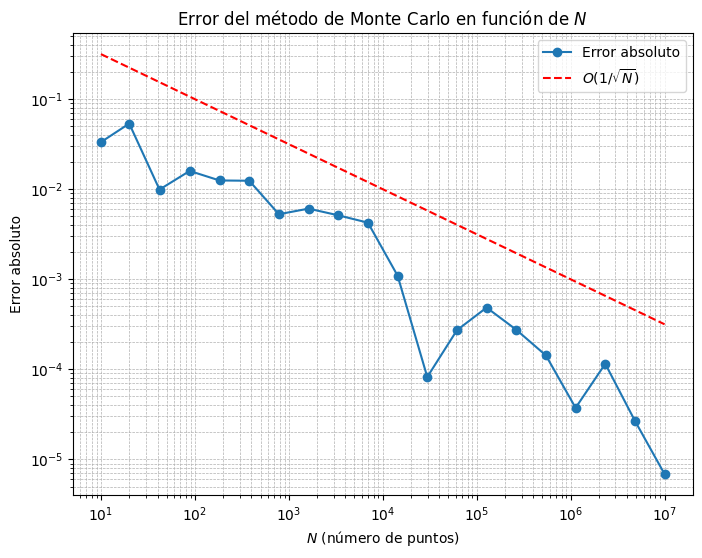

In [ ]:
# Valor teórico de la integral
exact_integral, _ = quad(lambda x: np.exp(-x**2), a, b)

# Valores de N para el análisis
N_values = np.logspace(1, 7, 20, dtype=int)  # De 10^1 a 10^5 usando 50 puntos
errors = []

# Calcular la integral y el error para cada N
for N in N_values:
    x = rng.uniform(a, b, N)
    f_x = np.exp(-x**2)
    monte_carlo_integral = (b - a) * np.mean(f_x)
    errors.append(abs(monte_carlo_integral - exact_integral))

# Graficar el error
plt.figure(figsize=(8, 6))
plt.loglog(N_values, errors, label="Error absoluto", marker="o", linestyle="-")
plt.loglog(N_values, 1 / np.sqrt(N_values), label="$O(1/\\sqrt{N})$", linestyle="--", color="red")
plt.title("Error del método de Monte Carlo en función de $N$")
plt.xlabel("$N$ (número de puntos)")
plt.ylabel("Error absoluto")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


### **Ejemplo 2: Integral en dos dimensiones**

Calcular el área bajo la función $f(x, y) = \sin(x) \cos(y)$ en el dominio $(x, y) \in [0, \pi] \times [0, \pi/2]$.

1. **Paso 1: Generar puntos aleatorios en el dominio.**
   Generamos $N$ puntos $(x_i, y_i)$ distribuidos uniformemente en $[0, \pi] \times [0, \pi/2]$.
2. **Paso 2: Evaluar la función.**
   Calculamos $f(x, y)$ para cada par $(x_i, y_i)$.
3. **Paso 3: Calcular la integral.**
   Usamos la fórmula:

$$
I \approx \frac{\text{Vol}(\Omega)}{N} \sum_{i=1}^N f(x_i, y_i),
$$

donde $\text{Vol}(\Omega) = \pi \cdot (\pi/2)$.

---



In [ ]:
# Parámetros
N = 10000  # Número de puntos
x_min, x_max = 0, np.pi
y_min, y_max = 0, np.pi / 2

# Generar puntos aleatorios
x = np.random.uniform(x_min, x_max, N)
y = np.random.uniform(y_min, y_max, N)

# Evaluar la función
f_xy = np.sin(x) * np.cos(y)

# Aproximar la integral
volumen = (x_max - x_min) * (y_max - y_min)
integral = volumen * np.mean(f_xy)

print(f'El valor de la integral será: {integral}')

El valor de la integral será: 1.9815821591786709


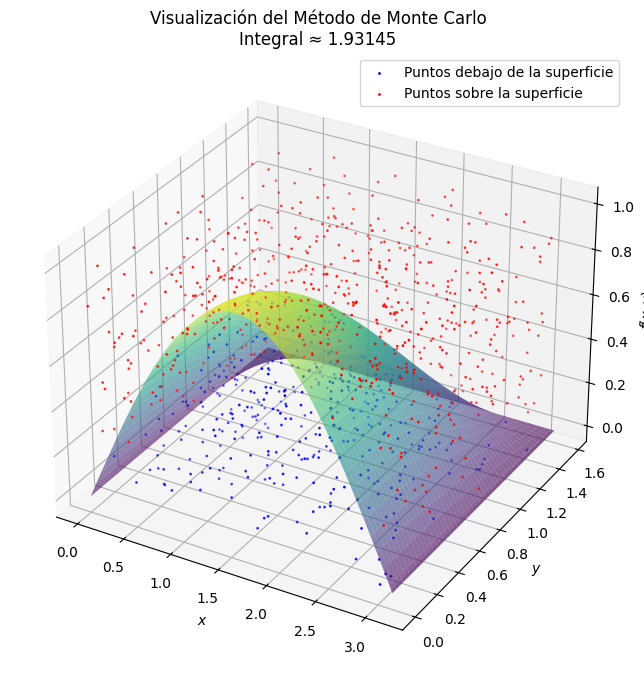

In [ ]:
# Parámetros
N = 1000  # Número de puntos
x_min, x_max = 0, np.pi
y_min, y_max = 0, np.pi / 2

# Generar puntos aleatorios
x = np.random.uniform(x_min, x_max, N)
y = np.random.uniform(y_min, y_max, N)

# Evaluar la función
f_xy = np.sin(x) * np.cos(y)

# Generar alturas aleatorias entre 0 y el valor máximo de f(x, y)
z = np.random.uniform(0, np.max(f_xy), N)

# Identificar puntos bajo la superficie
below_surface = z <= f_xy

# Aproximar la integral (volumen) usando Monte Carlo
volumen = (x_max - x_min) * (y_max - y_min)
integral = volumen * np.mean(f_xy)

# Crear una malla para la superficie
x_surface = np.linspace(x_min, x_max, 100)
y_surface = np.linspace(y_min, y_max, 100)
x_mesh, y_mesh = np.meshgrid(x_surface, y_surface)
z_surface = np.sin(x_mesh) * np.cos(y_mesh)

# Crear el gráfico
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Superficie de la función
ax.plot_surface(x_mesh, y_mesh, z_surface, cmap='viridis', alpha=0.6)

# Puntos debajo de la superficie
ax.scatter(x[below_surface], y[below_surface], z[below_surface], color="blue", s=1, label="Puntos debajo de la superficie")
# Puntos sobre la superficie
ax.scatter(x[~below_surface], y[~below_surface], z[~below_surface], color="red", s=1, label="Puntos sobre la superficie")

# Título con el valor de la integral
ax.set_title(f"Visualización del Método de Monte Carlo\nIntegral ≈ {integral:.5f}")

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$f(x, y)$")

# Mostrar leyenda
ax.legend()




# Hacer el gráfico interactivo
plt.ion()  # Habilita la interactividad

plt.show()